# NGC 2477 Open Cluster Age and Distance

This is a NASA SEES summer internship project. The goal is to determine age and distance of NGC2477 open cluster


In [1]:
# Global definitions

B_STACK = "/data/projects/NASA_SEES/project/data/NGC_2477_b_stacked.fits"
V_STACK = "/data/projects/NASA_SEES/project/data/NGC_2477_v_stacked.fits"
R_STACK = "/data/projects/NASA_SEES/project/data/NGC_2477_r_stacked.fits"
OUTPUT = "/data/projects/NASA_SEES/project/data/NGC2477.csv"
RAW_OUTPUT = "/data/projects/NASA_SEES/project/data/NGC2477_raw.csv"
OUTPUT_FILTERED = "/data/projects/NASA_SEES/project/data/NGC2477_filtered.csv"
OUTPUT_CALCED = "/data/projects/NASA_SEES/project/data/NGC2477_calculated.csv"
NOT_BELONG = "/data/projects/NASA_SEES/project/data/NGC2477_not_belong.csv"
CMD_PLOT = "/data/projects/NASA_SEES/project/data/NGC2477_CMD.png"

# Aperture settings in pixels
APERTURE_RADIUS = 6
SKY_INNER = 10
SKY_OUTER = 18

# Selection goal
N_TARGET = 1000
N_MAG_BIN = 30

# Detection / filtering parameters
DETECTION_SIGMA = 5.0
FWHM_INIT = 5.0
EDGE_MARGIN = SKY_OUTER + 3
# SATURATION_LEVEL = 60000

# Safety filters
FWHM_OVERLAP_FACTOR = 2.0
PHOTOMETRY_SAFETY_DISTANCE = SKY_OUTER + 4
# Stricter check against ALL raw DAO detections.
# This removes stars whose aperture/sky annulus would be contaminated by nearby stars.
RAW_CONTAMINATION_DISTANCE = 20 #32
MIN_SNR = 5.0
MAX_FWHM = 20.0
MIN_PEAK_ABOVE_BG = 200

#run control
RUN_VISUAL_CHECK = False


## 1. Import libraries

This notebook uses `astropy`, `photutils`, `scipy`, `pandas`, `plotly`, `nbformat`, and `matplotlib`.

If needed:

```bash
pip install astropy photutils scipy pandas matplotlib
```


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from scipy.spatial import cKDTree
import warnings


/home/jamesliang/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load the V stacked FITS image

The V image is used as the master image because it usually gives good signal for both blue and red stars.


In [3]:
with fits.open(V_STACK) as hdul:
    data = hdul[0].data.astype(float)
    header = hdul[0].header

ny, nx = data.shape
print(f"Loaded {V_STACK}: {nx} x {ny}")
print("Filter:", header.get("FILTER", "Unknown"))

mean, median, std = sigma_clipped_stats(data, sigma=3.0)
print(f"Background median = {median:.2f}, std = {std:.2f}")

Loaded /data/projects/NASA_SEES/project/data/NGC_2477_v_stacked.fits: 2048 x 2048
Filter: Bessell_V
Background median = 3787.77, std = 57.45


## 3. Detect candidate stars

The next a few cells detect stars in the `V` stacked FITS image and selects a clean list of stars for aperture photometry.

It removes stars that are likely problematic:
- overlapping based on FWHM
- too close to nearby stars for aperture/sky-annulus photometry
- too close to image edge
- saturated
- too faint/noisy

The final output file is `NGC2477.csv` with integer IDs, ImageJ X/Y coordinates, relative magnitude, and quality columns.
`DAOStarFinder` detects star-like peaks. The initial FWHM is only a starting guess; later we estimate local FWHM for quality filtering.

### `DAOStarFinder` Parameters

`DAOStarFinder` (https://photutils.readthedocs.io/en/stable/api/photutils.detection.DAOStarFinder.html) detects star-like objects by searching for bright peaks that match the expected shape of a star.

| Parameter | Description |
|-----------|-------------|
| `threshold` | Minimum brightness above the background required to detect a star. Lower values detect more stars but also more noise. |
| `fwhm` | Expected Full Width at Half Maximum (FWHM) of a typical star in pixels. Used to match the detection kernel to the star size. |
| `sharplo` | Minimum allowed sharpness. Rejects objects that are too broad to be stars. |
| `sharphi` | Maximum allowed sharpness. Rejects objects that are too sharp, such as hot pixels or cosmic rays. |
| `roundlo` | Minimum allowed roundness. Rejects objects that are excessively elongated. |
| `roundhi` | Maximum allowed roundness. Rejects objects elongated in the opposite direction. |
| `peakmax` | Maximum allowed peak pixel value. Useful for rejecting saturated stars. Default is `None` (no upper limit). |
| `exclude_border` | If `True`, ignores detections too close to the image edge. |
| `brightest` | Optionally keeps only the brightest *N* detected stars. Default is `None` (keep all). |

For this project, the most important parameters are **`threshold`**, which controls how many stars are detected, and **`fwhm`**, which describes the expected size of a star.


In [4]:
finder = DAOStarFinder(
    fwhm=FWHM_INIT,
    threshold= DETECTION_SIGMA * std
)

sources = finder(data - median)

if sources is None or len(sources) == 0:
    raise RuntimeError("No stars detected. Try lowering DETECTION_SIGMA or adjusting FWHM_INIT.")

df = sources.to_pandas()
df = df.rename(columns={"xcentroid": "x_centroid", "ycentroid": "y_centroid", "mag": "magnitude"})

df["ImageJ_X"] = df["x_centroid"]
df["ImageJ_Y"] = data.shape[0] - 1 - df["y_centroid"]


print(f"Detected candidate stars: {len(df)}")
df.shape
df.head()
df.to_csv(RAW_OUTPUT, index=False)


Detected candidate stars: 1445


## 4. Estimate FWHM for each detected star

A simple local half-maximum method is used to reject clearly blended or abnormal detections. Although stars are point sources in space, they appear as small blurred spots rather than single pixels in CCD images. The size of this spot is commonly described by its Full Width at Half Maximum (FWHM), which measures the width of the star's brightness profile. By estimating the FWHM for every detected star, we can identify detections that are significantly larger or smaller than typical stars. These unusual detections are more likely to be blended stars, cosmic rays, or other unreliable measurements and can be filtered before performing aperture photometry.
### Full Width at Half Maximum (FWHM)

FWHM (Full Width at Half Maximum) measures the apparent size of a star in an image. It is defined as the width of the star's brightness profile measured at **half of its peak brightness**.

- **Small FWHM** → sharp, well-focused star.
- **Large FWHM** → blurry star or possibly two overlapping stars.

`DAOStarFinder` uses the expected FWHM to recognize star-like objects. In this notebook, we also estimate each detected star's FWHM and reject stars with unusually large values, since they are more likely to be blended with nearby stars.

In [5]:
def estimate_fwhm_local(image, x, y, box=15):
    # Estimate FWHM from a small image cutout using area above half maximum.
    x0, y0 = int(round(x)), int(round(y))
    half = box // 2

    x1, x2 = max(0, x0 - half), min(image.shape[1], x0 + half + 1)
    y1, y2 = max(0, y0 - half), min(image.shape[0], y0 + half + 1)
    cutout = image[y1:y2, x1:x2]

    if cutout.size == 0:
        return np.nan

    local_median = np.median(cutout)
    peak = np.max(cutout)
    height = peak - local_median

    if height <= 0:
        return np.nan

    half_max = local_median + 0.5 * height
    area = np.sum(cutout >= half_max)

    # Approximate FWHM as diameter of a circle with the same half-max area.
    return 2.0 * np.sqrt(area / np.pi)

df["fwhm_px"] = [
    estimate_fwhm_local(data, x, y)
    for x, y in zip(df["x_centroid"], df["y_centroid"])
]

median_fwhm = np.nanmedian(df["fwhm_px"])
print(f"Median estimated FWHM = {median_fwhm:.2f} px")


Median estimated FWHM = 5.53 px


## 5. Add quality measurements

We compute nearest-neighbor distance, edge distance, peak value, simple SNR estimate, and relative magnitude.

In crowded star fields, nearby stars can overlap within the photometry aperture, causing their light to blend together and producing inaccurate brightness measurements. To identify these cases efficiently, a KD-tree (k-dimensional tree) is built from the detected star coordinates, allowing the nearest neighboring star for each detection to be found much faster than comparing every pair of stars. The nearest-neighbor distance is then compared with the chosen aperture size, and stars with neighbors that are too close are excluded because their photometry is more likely to be contaminated by overlapping light. This filtering step improves the overall reliability of the measured magnitudes used in the subsequent color–magnitude diagram (CMD).


In [6]:
coords = np.column_stack([df["x_centroid"].values, df["y_centroid"].values])
tree = cKDTree(coords)
dist, idx = tree.query(coords, k=2)
df["nearest_neighbor_px"] = dist[:, 1]

# Nearest neighbor among ALL raw DAO detections.
# This is the key crowding metric for photometry safety.
df["nearest_raw_detection_px"] = dist[:, 1]

df["edge_distance_px"] = np.minimum.reduce([
    df["x_centroid"].values,
    df["y_centroid"].values,
    nx - df["x_centroid"].values,
    ny - df["y_centroid"].values
])

def peak_value(image, x, y, box=5):
    x0, y0 = int(round(x)), int(round(y))
    half = box // 2
    x1, x2 = max(0, x0 - half), min(image.shape[1], x0 + half + 1)
    y1, y2 = max(0, y0 - half), min(image.shape[0], y0 + half + 1)
    return np.max(image[y1:y2, x1:x2])

df["peak"] = [peak_value(data, x, y) for x, y in zip(df["x_centroid"], df["y_centroid"])]

# SNR estimate from DAOStarFinder flux.
df["snr"] = df["flux"] / (std * np.sqrt(np.maximum(df["n_pixels"], 1)))

# Relative magnitude: smaller value = brighter star.
df["relative_mag"] = -2.5 * np.log10(np.maximum(df["flux"], 1e-12))


## 6. Apply filters

Key separation filters:

1. **FWHM overlap filter**: reject stars where the nearest neighbor is closer than `2 × FWHM`.
2. **Crowding filter**: Stars with a nearby neighbor that could overlap the APERTURE_RADIUS (6 px) aperture or the SKY_INNER–SKY_OUTER (10–18 px) sky annulus are excluded to reduce contamination from overlapping light.


In [ ]:
df["pass_fwhm_overlap"] = df["nearest_neighbor_px"] >= FWHM_OVERLAP_FACTOR * df["fwhm_px"]
df["pass_photometry_safety"] = df["nearest_raw_detection_px"] >= RAW_CONTAMINATION_DISTANCE
df["pass_edge"] = df["edge_distance_px"] >= EDGE_MARGIN
# df["pass_saturation"] = df["peak"] < SATURATION_LEVEL
df["pass_snr"] = df["snr"] >= MIN_SNR
df["peak_above_bg"] = df["peak"] - median
df["pass_peak_strength"] = df["peak_above_bg"] >= MIN_PEAK_ABOVE_BG
df["pass_fwhm_valid"] = np.isfinite(df["fwhm_px"]) & (df["fwhm_px"] > 1.5) & (df["fwhm_px"] < MAX_FWHM)
# df["pass_not_blended"] = df["fwhm_px"] < MAX_FWHM

filters = [
    "pass_fwhm_overlap",
    "pass_photometry_safety",
    "pass_edge",
    # "pass_saturation",
    "pass_snr",
    "pass_peak_strength",
    "pass_fwhm_valid",
]

df["clean"] = df[filters].all(axis=1)

print("Filter summary:")
for f in filters:
    print(f"{f:24s}: {df[f].sum():5d} / {len(df)}")

clean = df[df["clean"]].copy()
print(f"\nClean stars after all filters: {len(clean)}")


Filter summary:
pass_fwhm_overlap       :  1445 / 1445
pass_photometry_safety  :  1183 / 1445
pass_edge               :  1410 / 1445
pass_snr                :  1376 / 1445
pass_peak_strength      :  1416 / 1445
pass_fwhm_valid         :  1442 / 1445

Clean stars after all filters: 1106


## 7. Select clean stars

The code keeps stars across different brightness levels using relative-magnitude bins.


In [8]:
def select_balanced_by_brightness(clean_df, n_target=300, n_bins=10):
    # Select stars across brightness bins, then fill remaining slots by quality.
    if len(clean_df) <= n_target:
        return clean_df.copy()

    work = clean_df.copy()

    work["quality_score"] = (
        work["nearest_neighbor_px"]
        + 0.2 * work["snr"]
        - 3.0 * np.abs(work["fwhm_px"] - np.nanmedian(work["fwhm_px"]))
    )

    work["mag_bin"] = pd.qcut(
        work["relative_mag"],
        q=min(n_bins, len(work)),
        labels=False,
        duplicates="drop"
    )

    selected_parts = []
    per_bin = max(1, n_target // work["mag_bin"].nunique())

    for _, group in work.groupby("mag_bin"):
        selected_parts.append(
            group.sort_values("quality_score", ascending=False).head(per_bin)
        )

    selected = pd.concat(selected_parts).drop_duplicates()

    if len(selected) < n_target:
        remaining = work.drop(index=selected.index)
        fill = remaining.sort_values("quality_score", ascending=False).head(n_target - len(selected))
        selected = pd.concat([selected, fill])

    return selected.sort_values("quality_score", ascending=False).head(n_target).copy()

selected = select_balanced_by_brightness(clean, max(N_TARGET, len(clean)), n_bins=N_MAG_BIN)

selected = selected.reset_index(drop=True)
selected["StarID"] = np.arange(1, len(selected) + 1)


print(f"Selected stars: {len(selected)}")
selected[["StarID", "ImageJ_X", "ImageJ_Y", "relative_mag", "nearest_neighbor_px", "fwhm_px", "snr"]].head()


Selected stars: 1106


,StarID,ImageJ_X,ImageJ_Y,relative_mag,nearest_neighbor_px,fwhm_px,snr
0,1,1633.984155,2020.196301,-13.250582,24.061855,6.282549,496.430257
1,2,1723.516208,2002.627833,-12.452556,30.133630,5.527906,238.038737
2,3,228.097602,1997.050816,-14.765557,49.960114,5.641896,2003.771321
3,4,1869.000304,1981.370506,-10.907815,21.599963,5.170883,57.378795
4,5,1535.122538,1978.273560,-12.801056,39.025754,5.527906,328.131464


## 8. Save output CSV

This CSV can be used as your team numbering catalog.


In [9]:
output_cols = [
    "StarID",
    "x_centroid",
    "y_centroid",
    "ImageJ_X",
    "ImageJ_Y",
    "relative_mag",
    "flux",
    "peak",
    "peak_above_bg",
    "snr",
    "fwhm_px",
    "nearest_neighbor_px",
    "nearest_raw_detection_px",
    "edge_distance_px",
]

selected[output_cols].to_csv(OUTPUT, index=False)
print(f"Saved {len(selected)} stars to {OUTPUT}")


Saved 1106 stars to /data/projects/NASA_SEES/project/data/NGC2477.csv


## 9. Quick visual check

This plot shows selected stars on the V image. Use it to confirm that selected stars are well distributed and not obviously blended.


In [10]:
if RUN_VISUAL_CHECK:
    import plotly.graph_objects as go

    vmin, vmax = np.percentile(data, [5, 99.5])

    if "id" in df.columns and "id" in selected.columns:
        not_selected = df[~df["id"].isin(selected["id"])].copy()
    else:
        not_selected = df.drop(index=selected.index, errors="ignore").copy()

    fig = go.Figure()

    fig.add_trace(
        go.Heatmap(
            z=np.flipud(data),
            colorscale="gray",
            zmin=vmin,
            zmax=vmax,
            showscale=False,
            hovertemplate="ImageJ X=%{x:.1f}<br>ImageJ Y=%{y:.1f}<extra></extra>",
        )
    )

    fig.add_trace(
        go.Scatter(
            x=not_selected["ImageJ_X"],
            y=not_selected["ImageJ_Y"],
            mode="markers",
            marker=dict(
                size=8,
                color="rgba(0,0,0,0)",
                line=dict(width=0),
            ),
            customdata=not_selected[["ImageJ_X", "ImageJ_Y"]].to_numpy(),
            hovertemplate=(
                "Not selected<br>"
                "ImageJ X=%{customdata[0]:.1f}<br>"
                "ImageJ Y=%{customdata[1]:.1f}<extra></extra>"
            ),
            name="Not selected",
            showlegend=False,
        )
    )

    fig.add_trace(
        go.Scatter(
            x=selected["ImageJ_X"],
            y=selected["ImageJ_Y"],
            mode="markers",
            marker=dict(size=8, symbol="circle-open", line=dict(width=2)),
            text=selected["StarID"],
            customdata=selected[["ImageJ_X", "ImageJ_Y"]].to_numpy(),
            hovertemplate=(
                "StarID=%{text}<br>"
                "ImageJ X=%{customdata[0]:.1f}<br>"
                "ImageJ Y=%{customdata[1]:.1f}<extra></extra>"
            ),
            name="Selected",
        )
    )

    fig.update_layout(
        title="Detected stars on V image",
        width=1000,
        height=1000,
        xaxis_title="ImageJ X",
        yaxis_title="ImageJ Y",
    )

    fig.update_xaxes(range=[0, data.shape[1]])
    fig.update_yaxes(range=[data.shape[0], 0], scaleanchor="x", scaleratio=1)

    fig.show()


## 10. Calculate V Magnitudes from Three Reference Stars

### Method

The V-band zero point is calculated independently from reference stars A, B, and C:

$$
Z_{V,i}=V_{\mathrm{catalog},i}-v_{\mathrm{inst},i}
$$

The adopted V zero point is the **median** of the three individual zero points. Using the median makes the calibration less sensitive to one reference star with an unusual color or problematic measurement. The same procedure is applied to the B image in Section 11.


In [11]:
# Three reference stars in the V stacked image.
# Fill in these values before running the cell.
V_REF_A_IMAGEJ_X = 1415.5832
V_REF_A_IMAGEJ_Y = 1974.1916
V_REF_A_MAG = 13.076

V_REF_B_IMAGEJ_X = 1913.0128516412224
V_REF_B_IMAGEJ_Y = 913.7237274484944
V_REF_B_MAG = 13.076

V_REF_C_IMAGEJ_X = 329.3088
V_REF_C_IMAGEJ_Y = 1816.6092
V_REF_C_MAG = 12.832

from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry

def imagej_to_data_xy(imagej_x, imagej_y, image_height):
    """Convert AstroImageJ coordinates to FITS/DAO coordinates."""
    data_x = np.asarray(imagej_x, dtype=float)
    data_y = image_height - 1 - np.asarray(imagej_y, dtype=float)
    return data_x, data_y

def aperture_flux_at_positions(image, x, y, r, sky_in, sky_out):
    """Return background-subtracted aperture flux."""
    positions = np.column_stack([
        np.atleast_1d(np.asarray(x, dtype=float)),
        np.atleast_1d(np.asarray(y, dtype=float)),
    ])

    aperture = CircularAperture(positions, r=r)
    annulus = CircularAnnulus(positions, r_in=sky_in, r_out=sky_out)

    aperture_table = aperture_photometry(image, aperture)
    annulus_table = aperture_photometry(image, annulus)

    aperture_sum = np.asarray(aperture_table["aperture_sum"], dtype=float)
    annulus_sum = np.asarray(annulus_table["aperture_sum"], dtype=float)

    sky_mean = annulus_sum / annulus.area
    return aperture_sum - sky_mean * aperture.area

v_reference_stars = [
    {"name": "A", "x": V_REF_A_IMAGEJ_X, "y": V_REF_A_IMAGEJ_Y, "mag": V_REF_A_MAG},
    {"name": "B", "x": V_REF_B_IMAGEJ_X, "y": V_REF_B_IMAGEJ_Y, "mag": V_REF_B_MAG},
    {"name": "C", "x": V_REF_C_IMAGEJ_X, "y": V_REF_C_IMAGEJ_Y, "mag": V_REF_C_MAG},
]

for ref in v_reference_stars:
    if not np.all(np.isfinite([ref["x"], ref["y"], ref["mag"]])):
        raise ValueError(
            f"Reference star {ref['name']} has missing V coordinates or magnitude."
        )

v_ref_imagej_x = np.array([ref["x"] for ref in v_reference_stars], dtype=float)
v_ref_imagej_y = np.array([ref["y"] for ref in v_reference_stars], dtype=float)
v_ref_catalog_mag = np.array([ref["mag"] for ref in v_reference_stars], dtype=float)

v_ref_x, v_ref_y = imagej_to_data_xy(
    v_ref_imagej_x,
    v_ref_imagej_y,
    data.shape[0],
)

v_ref_fluxes = aperture_flux_at_positions(
    data,
    v_ref_x,
    v_ref_y,
    APERTURE_RADIUS,
    SKY_INNER,
    SKY_OUTER,
)

if np.any(v_ref_fluxes <= 0):
    bad_names = [
        v_reference_stars[i]["name"]
        for i in np.where(v_ref_fluxes <= 0)[0]
    ]
    raise ValueError(
        f"Non-positive V reference flux for star(s): {bad_names}. "
        "Check their coordinates."
    )

v_ref_inst_mags = -2.5 * np.log10(v_ref_fluxes)
v_zero_points = v_ref_catalog_mag - v_ref_inst_mags
v_zero_point = float(np.median(v_zero_points))

for i, ref in enumerate(v_reference_stars):
    print(
        f"Reference {ref['name']}: "
        f"ImageJ=({ref['x']:.2f}, {ref['y']:.2f}), "
        f"flux={v_ref_fluxes[i]:.2f}, "
        f"V ZP={v_zero_points[i]:.4f}"
    )

print(f"Adopted median V zero point: {v_zero_point:.4f}")

selected["V_flux"] = aperture_flux_at_positions(
    data,
    selected["x_centroid"],
    selected["y_centroid"],
    APERTURE_RADIUS,
    SKY_INNER,
    SKY_OUTER,
)

selected["V_inst_mag"] = np.where(
    selected["V_flux"] > 0,
    -2.5 * np.log10(selected["V_flux"]),
    np.nan,
)

selected["V_mag"] = selected["V_inst_mag"] + v_zero_point
selected = selected.sort_values("StarID").reset_index(drop=True)

selected = selected[
    [
        "StarID",
        "x_centroid",
        "y_centroid",
        "ImageJ_X",
        "ImageJ_Y",
        "V_flux",
        "V_inst_mag",
        "V_mag",
    ]
]
selected.rename(
    columns={
        "x_centroid": "V_x_centroid",
        "y_centroid": "V_y_centroid",
        "ImageJ_X": "V_ImageJ_X",
        "ImageJ_Y": "V_ImageJ_Y",
    },
    inplace=True,
)

selected.to_csv(OUTPUT, index=False)
print(selected.head(20))


Reference A: ImageJ=(1415.58, 1974.19), flux=1456654.81, V ZP=28.4844
Reference B: ImageJ=(1913.01, 913.72), flux=6583901.29, V ZP=30.1222
Reference C: ImageJ=(329.31, 1816.61), flux=1840016.07, V ZP=28.4941
Adopted median V zero point: 28.4941
    StarID  V_x_centroid  V_y_centroid   V_ImageJ_X   V_ImageJ_Y  \
0        1   1633.984155     26.803699  1633.984155  2020.196301   
1        2   1723.516208     44.372167  1723.516208  2002.627833   
2        3    228.097602     49.949184   228.097602  1997.050816   
3        4   1869.000304     65.629494  1869.000304  1981.370506   
4        5   1535.122538     68.726440  1535.122538  1978.273560   
5        6    712.288048     72.485713   712.288048  1974.514287   
6        7   1415.511279     72.699252  1415.511279  1974.300748   
7        8   1963.164023     73.778044  1963.164023  1973.221956   
8        9   1299.297410     75.383901  1299.297410  1971.616099   
9       10   1850.271513     76.390107  1850.271513  1970.609893   
10     

/home/jamesliang/.local/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 11. Calculate B Magnitudes from the B Stacked Image

The B-image positions of reference stars A, B, and C are obtained from their V-image positions using the validated constant image offset. An individual B zero point is calculated for each reference star, and the adopted B zero point is their median.


In [12]:
# B-image alignment relative to the V image.
B_OFFSET_X = -7.63
B_OFFSET_Y = -9.27

# Fill in the catalog B magnitudes before running the cell.
B_REF_A_MAG = 13.693
B_REF_B_MAG = 13.447
B_REF_C_MAG = 13.351

with fits.open(B_STACK) as hdul:
    b_data = hdul[0].data.astype(float)

b_reference_stars = [
    {
        "name": "A",
        "v_x": V_REF_A_IMAGEJ_X,
        "v_y": V_REF_A_IMAGEJ_Y,
        "mag": B_REF_A_MAG,
    },
    {
        "name": "B",
        "v_x": V_REF_B_IMAGEJ_X,
        "v_y": V_REF_B_IMAGEJ_Y,
        "mag": B_REF_B_MAG,
    },
    {
        "name": "C",
        "v_x": V_REF_C_IMAGEJ_X,
        "v_y": V_REF_C_IMAGEJ_Y,
        "mag": B_REF_C_MAG,
    },
]

for ref in b_reference_stars:
    if not np.all(np.isfinite([ref["v_x"], ref["v_y"], ref["mag"]])):
        raise ValueError(
            f"Reference star {ref['name']} has missing B magnitude or V-image coordinates."
        )

b_ref_imagej_x = np.array(
    [ref["v_x"] + B_OFFSET_X for ref in b_reference_stars],
    dtype=float,
)
b_ref_imagej_y = np.array(
    [ref["v_y"] + B_OFFSET_Y for ref in b_reference_stars],
    dtype=float,
)
b_ref_catalog_mag = np.array(
    [ref["mag"] for ref in b_reference_stars],
    dtype=float,
)

b_ref_x, b_ref_y = imagej_to_data_xy(
    b_ref_imagej_x,
    b_ref_imagej_y,
    b_data.shape[0],
)

b_ref_fluxes = aperture_flux_at_positions(
    b_data,
    b_ref_x,
    b_ref_y,
    APERTURE_RADIUS,
    SKY_INNER,
    SKY_OUTER,
)

if np.any(b_ref_fluxes <= 0):
    bad_names = [
        b_reference_stars[i]["name"]
        for i in np.where(b_ref_fluxes <= 0)[0]
    ]
    raise ValueError(
        f"Non-positive B reference flux for star(s): {bad_names}. "
        "Check the coordinates and B-image offsets."
    )

b_ref_inst_mags = -2.5 * np.log10(b_ref_fluxes)
b_zero_points = b_ref_catalog_mag - b_ref_inst_mags
b_zero_point = float(np.median(b_zero_points))

for i, ref in enumerate(b_reference_stars):
    print(
        f"Reference {ref['name']}: "
        f"B ImageJ=({b_ref_imagej_x[i]:.2f}, {b_ref_imagej_y[i]:.2f}), "
        f"flux={b_ref_fluxes[i]:.2f}, "
        f"B ZP={b_zero_points[i]:.4f}, "
        f"B-V ZP difference={b_zero_points[i] - v_zero_points[i]:.4f}"
    )

print(f"Adopted median B zero point: {b_zero_point:.4f}")
print(f"Adopted B-V zero-point difference: {b_zero_point - v_zero_point:.4f}")

selected["B_ImageJ_X"] = selected["V_ImageJ_X"] + B_OFFSET_X
selected["B_ImageJ_Y"] = selected["V_ImageJ_Y"] + B_OFFSET_Y

selected["B_x_centroid"], selected["B_y_centroid"] = imagej_to_data_xy(
    selected["B_ImageJ_X"],
    selected["B_ImageJ_Y"],
    b_data.shape[0],
)

selected["B_flux"] = aperture_flux_at_positions(
    b_data,
    selected["B_x_centroid"],
    selected["B_y_centroid"],
    APERTURE_RADIUS,
    SKY_INNER,
    SKY_OUTER,
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in log10",
    category=RuntimeWarning,
)
selected["B_inst_mag"] = np.where(
    selected["B_flux"] > 0,
    -2.5 * np.log10(selected["B_flux"]),
    np.nan,
)

selected["B_mag"] = selected["B_inst_mag"] + b_zero_point
selected.to_csv(OUTPUT, index=False)

selected[
    [
        "StarID",
        "V_ImageJ_X",
        "V_ImageJ_Y",
        "V_flux",
        "V_inst_mag",
        "V_mag",
        "B_ImageJ_X",
        "B_ImageJ_Y",
        "B_flux",
        "B_inst_mag",
        "B_mag",
    ]
].head(20)


Reference A: B ImageJ=(1407.95, 1964.92), flux=721644.15, B ZP=28.3388, B-V ZP difference=-0.1456
Reference B: B ImageJ=(1905.38, 904.45), flux=2356843.15, B ZP=29.3778, B-V ZP difference=-0.7444
Reference C: B ImageJ=(321.68, 1807.34), flux=928918.56, B ZP=28.2709, B-V ZP difference=-0.2231
Adopted median B zero point: 28.3388
Adopted B-V zero-point difference: -0.1552


,StarID,V_ImageJ_X,V_ImageJ_Y,V_flux,V_inst_mag,V_mag,B_ImageJ_X,B_ImageJ_Y,B_flux,B_inst_mag,B_mag
0,1,1633.984155,2020.196301,4.542555e+05,-14.143251,14.350803,1626.354155,2010.926301,444773.400821,-14.120347,14.218461
1,2,1723.516208,2002.627833,2.544212e+05,-13.513883,14.980171,1715.886208,1993.357833,75967.977366,-12.201576,16.137231
2,3,228.097602,1997.050816,1.228108e+06,-15.223091,13.270963,220.467602,1987.780816,694514.446877,-14.604203,13.734605
3,4,1869.000304,1981.370506,8.017368e+04,-12.260079,16.233975,1861.370304,1972.100506,39384.251686,-11.488306,16.850501
4,5,1535.122538,1978.273560,2.320278e+05,-13.413850,15.080204,1527.492538,1969.003560,93477.314620,-12.426766,15.912042
5,6,712.288048,1974.514287,4.603305e+04,-11.657674,16.836380,704.658048,1965.244287,7930.079485,-9.748194,18.590614
6,7,1415.511279,1974.300748,1.457678e+06,-15.409154,13.084900,1407.881279,1965.030748,722162.076797,-14.646587,13.692221
7,8,1963.164023,1973.221956,1.088476e+06,-15.092047,13.402007,1955.534023,1963.951956,558168.764224,-14.366914,13.971894
8,9,1299.297410,1971.616099,3.134172e+04,-11.240307,17.253747,1291.667410,1962.346099,3864.150822,-8.967635,19.371173
9,10,1850.271513,1970.609893,1.094160e+05,-12.597702,15.896352,1842.641513,1961.339893,41744.532966,-11.551499,16.787309


## 12. Filter and Calculate Corrected Photometry

This section removes stars with `B_mag > 18` or `V_mag > 18`, saves the filtered table, calculates corrected photometry columns, and saves the final calculated table.


In [13]:
BMV_ReddenAdjustment = 0.25
V_ReddenAdjustment = 0.25 * 3.2
filtered = selected[
    selected["B_mag"].notna()
    & selected["V_mag"].notna()
    # & (selected["B_mag"] <= 18)
    # & (selected["V_mag"] <= 18)
].copy()

filtered.to_csv(OUTPUT_FILTERED, index=False)
print(f"Saved {len(filtered)} filtered stars to {OUTPUT_FILTERED}")

calculated = filtered.copy()
calculated["BMV"] = calculated["B_mag"] - calculated["V_mag"]
calculated["BMV_Corrected"] = calculated["BMV"] - BMV_ReddenAdjustment
calculated["V_Corrected"] = calculated["V_mag"] - V_ReddenAdjustment

# calculated = calculated[(calculated["BMV_Corrected"] > 1.0)
#                         & (calculated["BMV_Corrected"] < 3.0)] # filter out outliers
calculated = calculated[
    calculated["BMV_Corrected"].between(-0.4, 2.0)
].copy()

calculated.to_csv(OUTPUT_CALCED, index=False)
print(f"Saved {len(calculated)} calculated stars to {OUTPUT_CALCED}")

calculated[
    ["StarID", "B_mag", "V_mag", "BMV", "BMV_Corrected", "V_Corrected"]
].head()


Saved 1047 filtered stars to /data/projects/NASA_SEES/project/data/NGC2477_filtered.csv
Saved 1024 calculated stars to /data/projects/NASA_SEES/project/data/NGC2477_calculated.csv


,StarID,B_mag,V_mag,BMV,BMV_Corrected,V_Corrected
0,1,14.218461,14.350803,-0.132343,-0.382343,13.550803
1,2,16.137231,14.980171,1.157060,0.907060,14.180171
2,3,13.734605,13.270963,0.463642,0.213642,12.470963
3,4,16.850501,16.233975,0.616527,0.366527,15.433975
4,5,15.912042,15.080204,0.831838,0.581838,14.280204


## 13. Estimate Distance and Attempt Age Measurement with a ZAMS Overlay

This section uses `calculated` dataframe before color-color outlier filtering. The ZAMS is shifted vertically to estimate the distance modulus and distance. At this stage, the unfiltered CMD does not show a sufficiently clear main-sequence turnoff, so the age is reported as unavailable rather than estimated.


Automatic ZAMS distance modulus: 11.84 mag
Adopted distance modulus:        11.84 mag
Estimated distance:              2,329 pc
                                 7,596 light-years


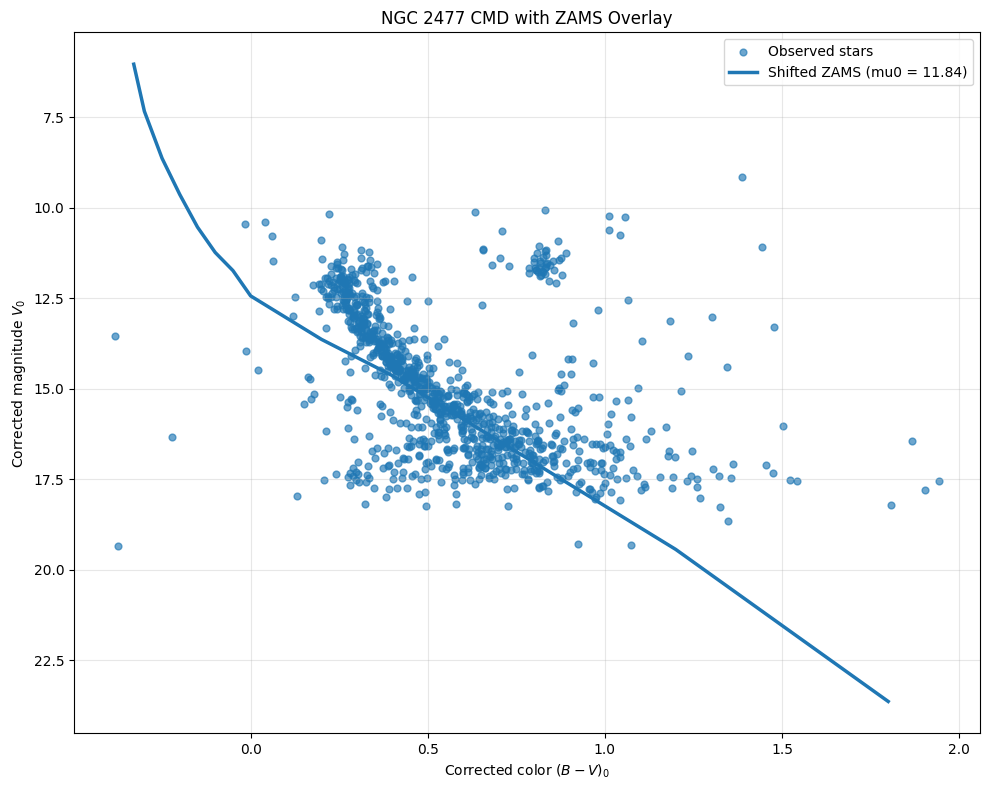

Age not estimated reliably before color-color outlier filtering: the main-sequence turnoff is not sufficiently clear.


,DistanceModulus,Distance_pc,Distance_light_years,EstimatedAge_Gyr
0,11.835664,2328.803773,7595.533233,NaN


,StarID,V_ImageJ_X,V_ImageJ_Y,B_mag,V_mag,BMV,BMV_Corrected,V_Corrected
0,1,1633.984155,2020.196301,14.218461,14.350803,-0.132343,-0.382343,13.550803
1076,1077,1014.395616,69.615356,20.019109,20.143714,-0.124605,-0.374605,19.343714
1101,1102,1746.253324,24.915824,17.152373,17.124969,0.027404,-0.222596,16.324969
779,780,1213.112248,688.312268,11.491714,11.256771,0.234944,-0.015056,10.456771
387,388,708.875007,1300.365342,14.997992,14.761917,0.236075,-0.013925,13.961917
297,298,2020.274307,1430.799814,15.562031,15.290028,0.272003,0.022003,14.490028
683,684,1336.817096,876.432258,11.496811,11.205780,0.291031,0.041031,10.405780
38,39,419.773377,1913.632725,11.891072,11.579480,0.311592,0.061592,10.779480
306,307,553.700507,1415.944211,12.589293,12.277272,0.312021,0.062021,11.477272
1105,1106,1725.933000,21.006250,14.171525,13.802623,0.368902,0.118902,13.002623


<Figure size 640x480 with 0 Axes>

In [14]:
# Approximate empirical ZAMS table: intrinsic (B-V)_0 and absolute V magnitude M_V.
# Values are intentionally low-resolution because this section is a heuristic overlay,
# not a replacement for a full theoretical isochrone fit.
zams = pd.DataFrame({
    "BMV_Corrected": [
        -0.33, -0.30, -0.25, -0.20, -0.15, -0.10, -0.05,
         0.00,  0.10,  0.20,  0.30,  0.40,  0.50,  0.60,
         0.70,  0.80,  0.90,  1.00,  1.10,  1.20,  1.30,
         1.40,  1.50,  1.60,  1.70,  1.80
    ],
    "M_V": [
        -5.8, -4.5, -3.2, -2.2, -1.3, -0.6, -0.1,
         0.6,  1.2,  1.8,  2.3,  2.8,  3.4,  4.0,
         4.6,  5.2,  5.8,  6.4,  7.0,  7.6,  8.3,
         9.0,  9.7, 10.4, 11.1, 11.8
    ],
})

cmd = calculated[["BMV_Corrected", "V_Corrected"]].dropna().copy()
cmd = cmd[
    cmd["BMV_Corrected"].between(zams["BMV_Corrected"].min(),
                                  zams["BMV_Corrected"].max())
].copy()

if len(cmd) < 10:
    raise RuntimeError("Too few stars lie within the ZAMS color range.")

# Interpolate the ZAMS absolute magnitude at every observed color.
cmd["ZAMS_MV"] = np.interp(
    cmd["BMV_Corrected"], zams["BMV_Corrected"], zams["M_V"]
)
cmd["IndividualDistanceModulus"] = cmd["V_Corrected"] - cmd["ZAMS_MV"]

# Main-sequence binaries and evolved stars tend to lie above the ZAMS.
# A high quantile therefore gives a practical initial vertical alignment.
DISTANCE_MODULUS_QUANTILE = 0.70
fitted_distance_modulus = cmd["IndividualDistanceModulus"].quantile(
    DISTANCE_MODULUS_QUANTILE
)

# Set this to a number after visually inspecting the overlay, or leave as None
# to use the automatic estimate above.
MANUAL_DISTANCE_MODULUS = None
distance_modulus = (
    fitted_distance_modulus
    if MANUAL_DISTANCE_MODULUS is None
    else float(MANUAL_DISTANCE_MODULUS)
)

distance_pc = 10 ** ((distance_modulus + 5.0) / 5.0)
distance_ly = distance_pc * 3.26156

print(f"Automatic ZAMS distance modulus: {fitted_distance_modulus:.2f} mag")
print(f"Adopted distance modulus:        {distance_modulus:.2f} mag")
print(f"Estimated distance:              {distance_pc:,.0f} pc")
print(f"                                 {distance_ly:,.0f} light-years")

# Plot the corrected CMD and vertically shifted ZAMS.
plt.figure(figsize=(10, 8))
plt.scatter(
    calculated["BMV_Corrected"],
    calculated["V_Corrected"],
    s=24,
    alpha=0.65,
    label="Observed stars",
)
plt.plot(
    zams["BMV_Corrected"],
    zams["M_V"] + distance_modulus,
    linewidth=2.5,
    label=f"Shifted ZAMS (mu0 = {distance_modulus:.2f})",
)
plt.xlabel(r"Corrected color $(B-V)_0$")
plt.ylabel(r"Corrected magnitude $V_0$")
plt.title("NGC 2477 CMD with ZAMS Overlay")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.savefig(CMD_PLOT, dpi=300, bbox_inches="tight")

# At this stage the CMD has not yet gone through color-color outlier filtering.
estimated_age_gyr = np.nan
print(
    "Age not estimated reliably before color-color outlier filtering: "
    "the main-sequence turnoff is not sufficiently clear."
)

zams_result = pd.DataFrame([{
    "DistanceModulus": distance_modulus,
    "Distance_pc": distance_pc,
    "Distance_light_years": distance_ly,
    "EstimatedAge_Gyr": estimated_age_gyr,
}])

# Display the 20 bluest stars in the current unfiltered calculated dataframe.
bluest_stars = calculated.nsmallest(20, "BMV_Corrected")[
    [
        "StarID",
        "V_ImageJ_X",
        "V_ImageJ_Y",
        "B_mag",
        "V_mag",
        "BMV",
        "BMV_Corrected",
        "V_Corrected",
    ]
]

display(zams_result)
display(bluest_stars)


## 14. Use the R Image for Color–Color Outlier Screening

This section uses the calibrated B, V, and R photometry to identify stars whose colors are inconsistent with the dominant stellar population in the image.

This is a **photometric outlier screening method**, not a definitive cluster-membership test. A field star can still have normal stellar colors and remain in the sample, while a true cluster member with unusual photometry could be flagged.

The procedure is:

1. Load the R stacked FITS image.

2. Convert each star’s V-image position to the corresponding R-image position using:

   $$
   X_R = X_V + R_{\mathrm{OFFSET},X}
   $$

   $$
   Y_R = Y_V + R_{\mathrm{OFFSET},Y}
   $$

3. Use the known R magnitude of the reference star to calculate the R-image photometric zero point.

4. Measure the background-subtracted R-band flux of every star and calculate its calibrated R magnitude.

5. Calculate each star’s calibrated V−R color:

   $$
   V-R = V_{\mathrm{mag}} - R_{\mathrm{mag}}
   $$

6. Plot each star conceptually in a color–color diagram using:

   - corrected B−V color on the x-axis
   - calibrated V−R color on the y-axis

   Normal stars tend to follow a common curved sequence called the **stellar color–color locus**.

7. Fit a quadratic curve to the dominant color–color locus. The fitting is repeated several times, temporarily excluding strong outliers so they do not distort the fitted curve.

8. For each star, calculate the difference between its measured V−R color and the V−R value predicted by the fitted locus.

9. Estimate the typical scatter around the locus using the median absolute deviation, which is less sensitive to outliers than the standard deviation.

10. Flag a star as a photometric non-member candidate when:

   - its R aperture falls outside the image,
   - its R flux is missing or nonpositive, or
   - its color–color residual is more than 3.5 robust standard deviations from the fitted stellar locus.

The flagged stars are stored in the `not_belong` dataframe using their `StarID`, `V_ImageJ_X`, and `V_ImageJ_Y` values.

The name `not_belong` should be interpreted cautiously. These stars are more accurately described as **photometric outlier candidates**, because B, V, and R colors alone cannot prove whether a star belongs to NGC 2477.

In [15]:
# R-image alignment relative to the V image.
# Start with zero only if the R and V stacks are already aligned.
# Definition:
# R_OFFSET_X = ImageJ_X(R) - ImageJ_X(V)
# R_OFFSET_Y = ImageJ_Y(R) - ImageJ_Y(V)
R_OFFSET_X = 3.24
R_OFFSET_Y = 10.19

# Robust color-color outlier threshold.
COLOR_LOCUS_SIGMA = 3.5

R_REF_MAG = 10.653

# Load the R stacked image.
with fits.open(R_STACK) as hdul:
    r_data = hdul[0].data.astype(float)

# Calibrate the R zero point using the same reference star.
R_REF_IMAGEJ_X = V_REF_B_IMAGEJ_X + R_OFFSET_X
R_REF_IMAGEJ_Y = V_REF_B_IMAGEJ_Y + R_OFFSET_Y
R_REF_X, R_REF_Y = imagej_to_data_xy(R_REF_IMAGEJ_X,R_REF_IMAGEJ_Y,r_data.shape[0])

r_ref_flux = aperture_flux_at_positions(
    r_data,[R_REF_X],[R_REF_Y],
    APERTURE_RADIUS,SKY_INNER,SKY_OUTER
)[0]

r_ref_inst_mag = -2.5*np.log10(r_ref_flux)
r_zero_point = R_REF_MAG - r_ref_inst_mag
print(f"R zero point: {r_zero_point:.4f}")

# Convert each V-image position to the corresponding R-image position.
r_phot = calculated.copy()
r_phot["R_ImageJ_X"] = r_phot["V_ImageJ_X"] + R_OFFSET_X
r_phot["R_ImageJ_Y"] = r_phot["V_ImageJ_Y"] + R_OFFSET_Y

r_phot["R_x_centroid"], r_phot["R_y_centroid"] = imagej_to_data_xy(
    r_phot["R_ImageJ_X"],
    r_phot["R_ImageJ_Y"],
    r_data.shape[0],
)

# Keep only apertures that remain fully inside the R image.
r_phot["R_position_valid"] = (
    (r_phot["R_x_centroid"] >= SKY_OUTER)
    & (r_phot["R_x_centroid"] < r_data.shape[1] - SKY_OUTER)
    & (r_phot["R_y_centroid"] >= SKY_OUTER)
    & (r_phot["R_y_centroid"] < r_data.shape[0] - SKY_OUTER)
)

r_phot["R_flux"] = np.nan

valid_r = r_phot["R_position_valid"]
r_phot.loc[valid_r, "R_flux"] = aperture_flux_at_positions(
    r_data,
    r_phot.loc[valid_r, "R_x_centroid"],
    r_phot.loc[valid_r, "R_y_centroid"],
    APERTURE_RADIUS,
    SKY_INNER,
    SKY_OUTER,
)

r_phot["R_inst_mag"] = np.where(
    r_phot["R_flux"] > 0,
    -2.5 * np.log10(r_phot["R_flux"]),
    np.nan,
)

r_phot["R_mag"] = r_phot["R_inst_mag"] + r_zero_point
r_phot["VR"] = r_phot["V_mag"] - r_phot["R_mag"]

# Use stars with valid B-V and V-R measurements to fit the dominant locus.
fit_mask = (
    np.isfinite(r_phot["BMV_Corrected"])
    & np.isfinite(r_phot["VR"])
)

fit_data = r_phot.loc[fit_mask].copy()

if len(fit_data) < 20:
    raise RuntimeError(
        "Too few valid R measurements to fit the color-color locus. "
        "Check R_OFFSET_X and R_OFFSET_Y."
    )

# Iteratively fit a quadratic color-color locus and remove strong outliers.
keep = np.ones(len(fit_data), dtype=bool)

for _ in range(4):
    x = fit_data.loc[keep, "BMV_Corrected"].to_numpy()
    y = fit_data.loc[keep, "VR"].to_numpy()

    coeff = np.polyfit(x, y, deg=2)
    predicted = np.polyval(coeff, fit_data["BMV_Corrected"].to_numpy())
    residual = fit_data["VR"].to_numpy() - predicted

    center = np.median(residual[keep])
    mad = np.median(np.abs(residual[keep] - center))
    robust_sigma = 1.4826 * mad

    if not np.isfinite(robust_sigma) or robust_sigma == 0:
        break

    keep = np.abs(residual - center) <= COLOR_LOCUS_SIGMA * robust_sigma

# Final residuals for every star with valid R photometry.
r_phot["VR_locus_expected"] = np.polyval(
    coeff,
    r_phot["BMV_Corrected"],
)

r_phot["VR_locus_residual"] = (
    r_phot["VR"] - r_phot["VR_locus_expected"]
)

final_center = np.median(residual[keep])
final_mad = np.median(np.abs(residual[keep] - final_center))
final_sigma = 1.4826 * final_mad

r_phot["not_belong_flag"] = (
    ~r_phot["R_position_valid"]
    | ~np.isfinite(r_phot["R_flux"])
    | (r_phot["R_flux"] <= 0)
    | (
        np.abs(r_phot["VR_locus_residual"] - final_center)
        > COLOR_LOCUS_SIGMA * final_sigma
    )
)

not_belong = r_phot.loc[
    r_phot["not_belong_flag"],
    [
        "StarID",
        "V_ImageJ_X",
        "V_ImageJ_Y"
    ],
].copy()

print(f"Valid R measurements: {fit_mask.sum()} / {len(r_phot)}")
print(f"Photometric non-member candidates: {len(not_belong)}")
print(not_belong.shape)
not_belong.head(20)
not_belong.to_csv(NOT_BELONG, index=False)


R zero point: 28.3681
Valid R measurements: 1019 / 1024
Photometric non-member candidates: 198
(198, 3)


## 15. Remove Photometric Non-Member Candidates and Regenerate the CMD

This section saves the flagged stars to `NOT_BELONG`, removes matching stars from `calculated`, and redraws the corrected CMD.

The matching is performed by `StarID`, while the saved CSV includes `V_ImageJ_X` and `V_ImageJ_Y`.


Saved 198 stars to /data/projects/NASA_SEES/project/data/NGC2477_not_belong.csv
Stars found in calculated and removed: 198
Remaining CMD stars: 826
Updated calculated data saved to /data/projects/NASA_SEES/project/data/NGC2477_calculated.csv


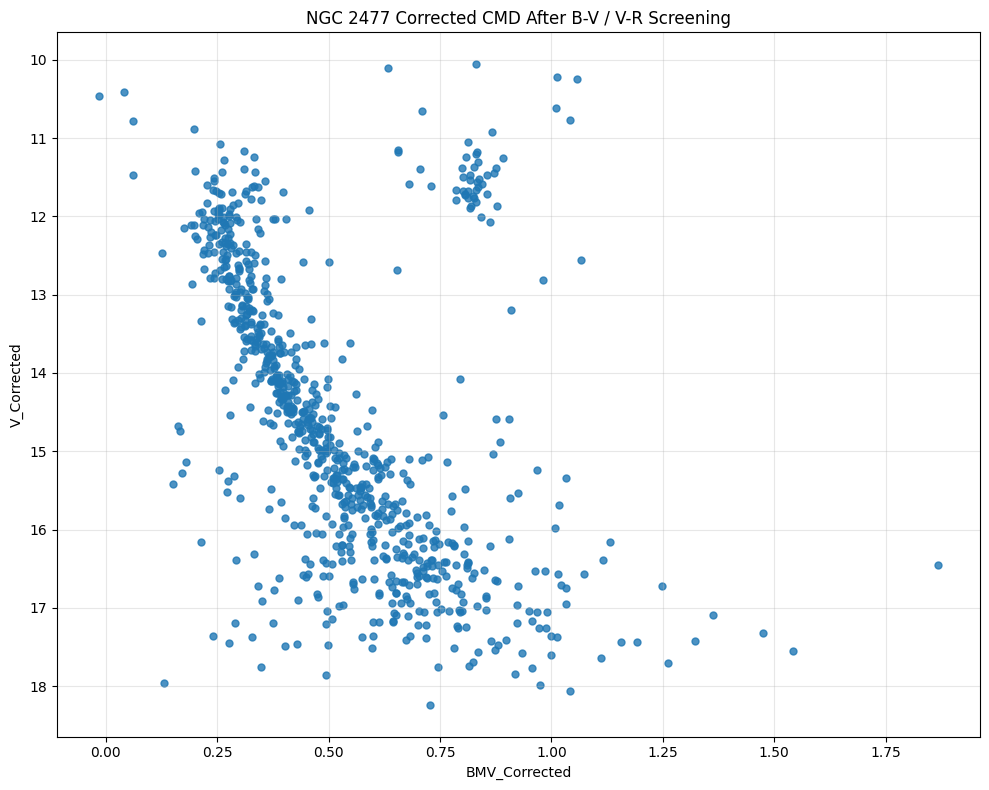

,StarID,V_ImageJ_X,V_ImageJ_Y,BMV_Corrected,V_Corrected
0,1,1633.984155,2020.196301,-0.382343,13.550803
1,2,1723.516208,2002.627833,0.907060,14.180171
2,3,228.097602,1997.050816,0.213642,12.470963
3,4,1869.000304,1981.370506,0.366527,15.433975
4,5,1535.122538,1978.273560,0.581838,14.280204
5,6,712.288048,1974.514287,1.504234,16.036380
6,7,1415.511279,1974.300748,0.357321,12.284900
11,12,846.428161,1964.952028,0.683346,15.752730
12,13,1462.643291,1965.094514,0.682068,16.809891
13,14,1256.759920,1962.608192,0.788282,16.863436


In [16]:
# Save stars flagged by the B-V / V-R color-color test.
not_belong.to_csv(NOT_BELONG, index=False)
print(f"Saved {len(not_belong)} stars to {NOT_BELONG}")

# Find stars from calculated that were flagged as not belonging.
not_belong_ids = set(not_belong["StarID"])

removed_from_calculated = calculated[
    calculated["StarID"].isin(not_belong_ids)
].copy()

print(
    f"Stars found in calculated and removed: "
    f"{len(removed_from_calculated)}"
)

# Remove flagged stars from calculated.
calculated = calculated[
    ~calculated["StarID"].isin(not_belong_ids)
].copy()

# Save the updated calculated table.
calculated.to_csv(OUTPUT_CALCED, index=False)
print(f"Remaining CMD stars: {len(calculated)}")
print(f"Updated calculated data saved to {OUTPUT_CALCED}")

# Regenerate the corrected CMD.
plt.figure(figsize=(10, 8))

plt.scatter(
    calculated["BMV_Corrected"],
    calculated["V_Corrected"],
    s=25,
    alpha=0.8,
)

plt.xlabel("BMV_Corrected")
plt.ylabel("V_Corrected")
plt.title("NGC 2477 Corrected CMD After B-V / V-R Screening")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

removed_from_calculated[
    [
        "StarID",
        "V_ImageJ_X",
        "V_ImageJ_Y",
        "BMV_Corrected",
        "V_Corrected",
    ]
].head(20)


## 16. Spectal Class
### Approximate Spectral Class from Corrected B−V Color

| Spectral Class | B−V Corrected Range |
|---------------|--------------------:|
| O | < -0.30 |
| B | -0.30 to < 0.00 |
| A | 0.00 to < 0.35 |
| F | 0.35 to < 0.60 |
| G | 0.60 to < 0.85 |
| K | 0.85 to < 1.30 |
| M | ≥ 1.30 |

This classification is an approximate mapping from corrected B−V color to the Morgan–Keenan (MK) spectral classes. It is intended for visualization and heuristic analysis rather than precise stellar classification.

In [17]:
def spectral_class_from_bmv(bmv):
    if pd.isna(bmv):
        return ""
    if bmv < -0.3:
        return "O"
    elif bmv < 0:
        return "B"
    elif bmv < 0.35:
        return "A"
    elif bmv < 0.6:
        return "F"
    elif bmv < 0.85:
        return "G"
    elif bmv < 1.3:
        return "K"
    else:
        return "M"

calculated["SpectralClass"] = calculated["BMV_Corrected"].apply(
    spectral_class_from_bmv
)
calculated.to_csv(OUTPUT_CALCED, index=False)

## 17. Estimate Distance and Age with a ZAMS Overlay

A Zero-Age Main Sequence (ZAMS) gives the expected absolute magnitude, $M_V$, for main-sequence stars of each intrinsic color, $(B-V)_0$. The code shifts the ZAMS vertically until it best overlaps the observed main sequence. This vertical shift is the distance modulus:

$$\mu_0 = V_0-M_V, \qquad d=10^{(\mu_0+5)/5}\ \mathrm{pc}.
$$

The cluster age is estimated separately from the main-sequence turnoff. The brightest plausible turnoff star is converted to an approximate stellar mass and main-sequence lifetime. This is a heuristic estimate; reliable age measurement normally requires fitting theoretical isochrones. If the CMD does not contain sufficiently blue main-sequence stars, the code reports that the age cannot be estimated reliably.


Automatic ZAMS distance modulus: 11.70 mag
Adopted distance modulus:        11.70 mag
Estimated distance:              2,188 pc
                                 7,136 light-years


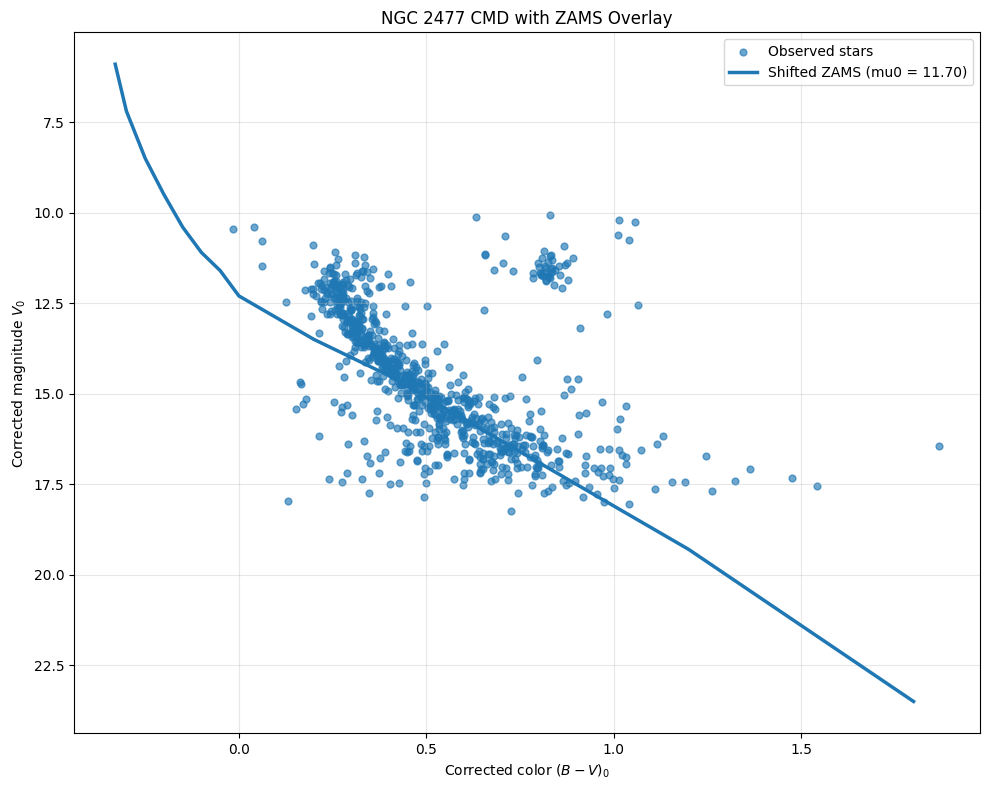

Approximate turnoff (B-V)_0:     0.30
Approximate turnoff M_V:         1.49
Approximate turnoff mass:        2.41 solar masses
Heuristic cluster age:           1.11 Gyr


,DistanceModulus,Distance_pc,Distance_light_years,EstimatedAge_Gyr
0,11.699995,2187.756939,7135.500522,1.113231


<Figure size 640x480 with 0 Axes>

In [18]:
# Approximate empirical ZAMS table: intrinsic (B-V)_0 and absolute V magnitude M_V.
# Values are intentionally low-resolution because this section is a heuristic overlay,
# not a replacement for a full theoretical isochrone fit.
zams = pd.DataFrame({
    "BMV_Corrected": [
        -0.33, -0.30, -0.25, -0.20, -0.15, -0.10, -0.05,
         0.00,  0.10,  0.20,  0.30,  0.40,  0.50,  0.60,
         0.70,  0.80,  0.90,  1.00,  1.10,  1.20,  1.30,
         1.40,  1.50,  1.60,  1.70,  1.80
    ],
    "M_V": [
        -5.8, -4.5, -3.2, -2.2, -1.3, -0.6, -0.1,
         0.6,  1.2,  1.8,  2.3,  2.8,  3.4,  4.0,
         4.6,  5.2,  5.8,  6.4,  7.0,  7.6,  8.3,
         9.0,  9.7, 10.4, 11.1, 11.8
    ],
})

cmd = calculated[["BMV_Corrected", "V_Corrected"]].dropna().copy()
cmd = cmd[
    cmd["BMV_Corrected"].between(zams["BMV_Corrected"].min(),
                                  zams["BMV_Corrected"].max())
].copy()

if len(cmd) < 10:
    raise RuntimeError("Too few stars lie within the ZAMS color range.")

# Interpolate the ZAMS absolute magnitude at every observed color.
cmd["ZAMS_MV"] = np.interp(
    cmd["BMV_Corrected"], zams["BMV_Corrected"], zams["M_V"]
)
cmd["IndividualDistanceModulus"] = cmd["V_Corrected"] - cmd["ZAMS_MV"]

# Main-sequence binaries and evolved stars tend to lie above the ZAMS.
# A high quantile therefore gives a practical initial vertical alignment.
DISTANCE_MODULUS_QUANTILE = 0.70
fitted_distance_modulus = cmd["IndividualDistanceModulus"].quantile(
    DISTANCE_MODULUS_QUANTILE
)

# Set this to a number after visually inspecting the overlay, or leave as None
# to use the automatic estimate above.
MANUAL_DISTANCE_MODULUS = None
distance_modulus = (
    fitted_distance_modulus
    if MANUAL_DISTANCE_MODULUS is None
    else float(MANUAL_DISTANCE_MODULUS)
)

distance_pc = 10 ** ((distance_modulus + 5.0) / 5.0)
distance_ly = distance_pc * 3.26156

print(f"Automatic ZAMS distance modulus: {fitted_distance_modulus:.2f} mag")
print(f"Adopted distance modulus:        {distance_modulus:.2f} mag")
print(f"Estimated distance:              {distance_pc:,.0f} pc")
print(f"                                 {distance_ly:,.0f} light-years")

# Plot the corrected CMD and vertically shifted ZAMS.
plt.figure(figsize=(10, 8))
plt.scatter(
    calculated["BMV_Corrected"],
    calculated["V_Corrected"],
    s=24,
    alpha=0.65,
    label="Observed stars",
)
plt.plot(
    zams["BMV_Corrected"],
    zams["M_V"] + distance_modulus,
    linewidth=2.5,
    label=f"Shifted ZAMS (mu0 = {distance_modulus:.2f})",
)
plt.xlabel(r"Corrected color $(B-V)_0$")
plt.ylabel(r"Corrected magnitude $V_0$")
plt.title("NGC 2477 CMD with ZAMS Overlay")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.savefig(CMD_PLOT, dpi=300, bbox_inches="tight")

# Heuristic main-sequence-turnoff age estimate.
# Restrict the search to relatively blue stars close to, or above, the shifted ZAMS.
cmd["Absolute_V"] = cmd["V_Corrected"] - distance_modulus
cmd["DeltaFromZAMS"] = cmd["Absolute_V"] - cmd["ZAMS_MV"]
turnoff_candidates = cmd[
    (cmd["BMV_Corrected"] <= 0.60)
    & (cmd["DeltaFromZAMS"].between(-1.5, 0.8))
].copy()

if len(turnoff_candidates) < 3:
    estimated_age_gyr = np.nan
    print(
        "Age not estimated reliably: the CMD contains too few plausible "
        "blue main-sequence/turnoff stars."
    )
else:
    # Use the bright end of the plausible turnoff population rather than one star.
    turnoff_mv = turnoff_candidates["Absolute_V"].quantile(0.20)
    turnoff_bmv = turnoff_candidates.loc[
        (turnoff_candidates["Absolute_V"] - turnoff_mv).abs().idxmin(),
        "BMV_Corrected",
    ]

    # Approximate conversion: M_V -> luminosity -> mass -> main-sequence lifetime.
    M_V_SUN = 4.83
    turnoff_luminosity = 10 ** (0.4 * (M_V_SUN - turnoff_mv))
    turnoff_mass = turnoff_luminosity ** (1.0 / 3.5)
    estimated_age_gyr = 10.0 * turnoff_mass ** (-2.5)

    print(f"Approximate turnoff (B-V)_0:     {turnoff_bmv:.2f}")
    print(f"Approximate turnoff M_V:         {turnoff_mv:.2f}")
    print(f"Approximate turnoff mass:        {turnoff_mass:.2f} solar masses")
    print(f"Heuristic cluster age:           {estimated_age_gyr:.2f} Gyr")

zams_result = pd.DataFrame([{
    "DistanceModulus": distance_modulus,
    "Distance_pc": distance_pc,
    "Distance_light_years": distance_ly,
    "EstimatedAge_Gyr": estimated_age_gyr,
}])

zams_result
